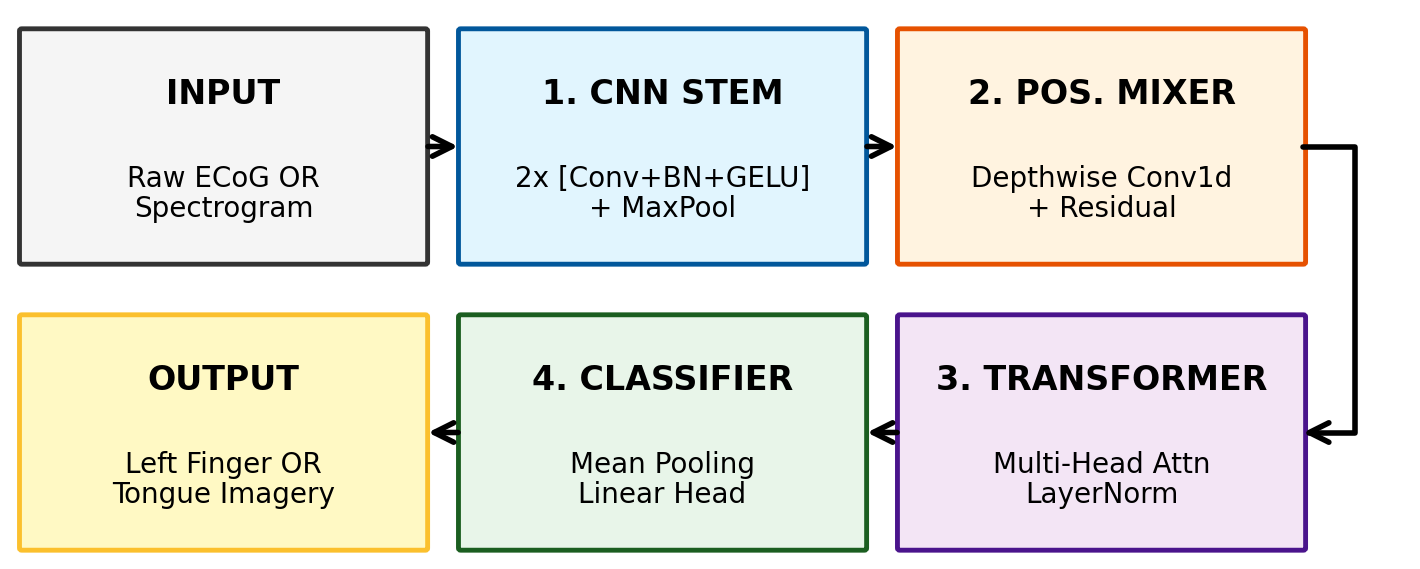

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def create_ultra_compact_diagram():
    # Adjusted figure size for a very tight, wide aspect ratio
    fig, ax = plt.subplots(figsize=(14, 5.5))
    
    # Tight coordinates to eliminate whitespace
    ax.set_xlim(0, 11.8)
    ax.set_ylim(0, 5.0)
    ax.axis('off')

    # Global dimensions - Large boxes for ultra-large text
    box_w, box_h = 3.4, 2.1
    title_size = 24  # Extremely large for poster visibility
    body_size = 20   # Extremely large for poster visibility
    
    def draw_node(x, y, title, content, color, edge_color):
        rect = patches.FancyBboxPatch(
            (x, y), box_w, box_h, 
            boxstyle="round,pad=0.02",
            facecolor=color, edgecolor=edge_color, linewidth=3.5
        )
        ax.add_patch(rect)
        
        # Title (Top half)
        ax.text(x + box_w/2, y + box_h*0.73, title, ha='center', va='center', 
                fontsize=title_size, fontweight='bold')
        
        # Content (Bottom half)
        ax.text(x + box_w/2, y + box_h*0.30, content, ha='center', va='center', 
                fontsize=body_size, linespacing=1.1)

    # --- ROW 1 (Y=2.7) ---
    draw_node(0.1, 2.7, "INPUT", "Raw ECoG OR\nSpectrogram", "#f5f5f5", "#333333")
    draw_node(3.8, 2.7, "1. CNN STEM", "2x [Conv+BN+GELU]\n+ MaxPool", "#e1f5fe", "#01579b")
    draw_node(7.5, 2.7, "2. POS. MIXER", "Depthwise Conv1d\n+ Residual", "#fff3e0", "#e65100")

    # --- ROW 2 (Y=0.1) ---
    draw_node(7.5, 0.1, "3. TRANSFORMER", "Multi-Head Attn\nLayerNorm", "#f3e5f5", "#4a148c")
    draw_node(3.8, 0.1, "4. CLASSIFIER", "Mean Pooling\nLinear Head", "#e8f5e9", "#1b5e20")
    draw_node(0.1, 0.1, "OUTPUT", "Left Finger OR\nTongue Imagery", "#fff9c4", "#fbc02d")

    # --- ARROWS ---
    # mutation_scale 35 for very large, visible arrowheads
    arrow_params = dict(arrowstyle="->", color="black", lw=4, mutation_scale=35)
    
    # Row 1 Horizontal (Centers at Y=3.75)
    ax.annotate("", xy=(3.8, 3.75), xytext=(3.5, 3.75), arrowprops=arrow_params)
    ax.annotate("", xy=(7.5, 3.75), xytext=(7.2, 3.75), arrowprops=arrow_params)
    
    # THE WRAP ARROW: Using 'bar' to create a squared-off bracket
    # fraction=0.18 makes the bracket extend to the right slightly
    wrap_arrow = patches.ConnectionPatch(
        xyA=(10.9, 3.75), xyB=(10.9, 1.15), coordsA='data', coordsB='data',
        arrowstyle="->", lw=4, mutation_scale=35, 
        connectionstyle="bar,fraction=-0.18,angle=90"
    )
    ax.add_patch(wrap_arrow)

    # Row 2 Horizontal (Right to Left, Centers at Y=1.15)
    ax.annotate("", xy=(7.2, 1.15), xytext=(7.5, 1.15), arrowprops=arrow_params)
    ax.annotate("", xy=(3.5, 1.15), xytext=(3.8, 1.15), arrowprops=arrow_params)

    # Tighten figure to edges
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    # Save with virtually no padding
    plt.savefig('architecture_poster_final.png', dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

create_ultra_compact_diagram()